<a href="https://colab.research.google.com/github/sidranasreen/alzheimers-detection-cnn/blob/main/Alzheimer_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
# Configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing Alzheimer's dataset

In [ ]:
# API to fetch dataset from kaggle
!kaggle datasets download -d sachinkumar413/alzheimer-mri-dataset

 93% 26.0M/28.0M [00:01<00:00, 24.5MB/s]
100% 28.0M/28.0M [00:01<00:00, 17.0MB/s]


In [ ]:
# extracting the compressed dataset
from zipfile import ZipFile
dataset='/content/alzheimer-mri-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print("The dataset is extracted")

The dataset is extracted


In [ ]:
# lsiting all the files present in the directory
!ls

alzheimer-mri-dataset.zip  Dataset  kaggle.json  sample_data


Importing the dependencies

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import tensorflow as tf

In [ ]:
# displaying list of mild_demented images in the particular directory
Mild_demented_files=os.listdir('/content/Dataset/Mild_Demented')
print(Mild_demented_files[0:10])
print(Mild_demented_files[-10:])

['mild_411.jpg', 'mild_109.jpg', 'mild_457.jpg', 'mild_637.jpg', 'mild_771.jpg', 'mild_122.jpg', 'mild_663.jpg', 'mild_842.jpg', 'mild_187.jpg', 'mild_412.jpg']
['mild_20.jpg', 'mild_767.jpg', 'mild_60.jpg', 'mild_685.jpg', 'mild_70.jpg', 'mild_519.jpg', 'mild_847.jpg', 'mild_552.jpg', 'mild_433.jpg', 'mild_296.jpg']


In [ ]:
# displaying list of moderate demented images
Moderate_demented_files=os.listdir('/content/Dataset/Moderate_Demented')
print(Moderate_demented_files[0:10])
print(Moderate_demented_files[-10:])

['moderate_36.jpg', 'moderate_64.jpg', 'moderate_18.jpg', 'moderate_56.jpg', 'moderate_43.jpg', 'moderate_63.jpg', 'moderate_60.jpg', 'moderate_2.jpg', 'moderate_53.jpg', 'moderate_30.jpg']
['moderate_15.jpg', 'moderate_62.jpg', 'moderate_33.jpg', 'moderate_27.jpg', 'moderate_49.jpg', 'moderate_3.jpg', 'moderate_22.jpg', 'moderate_29.jpg', 'moderate_28.jpg', 'moderate_42.jpg']


In [ ]:
# displaying list of Non_demented images
Non_demented_files=os.listdir('/content/Dataset/Non_Demented')
print(Non_demented_files[0:10])
print(Non_demented_files[-10:])

['non_1457.jpg', 'non_4.jpg', 'non_828.jpg', 'non_1957.jpg', 'non_1644.jpg', 'non_549.jpg', 'non_2259.jpg', 'non_614.jpg', 'non_1382.jpg', 'non_1052.jpg']
['non_223.jpg', 'non_2368.jpg', 'non_1504.jpg', 'non_2426.jpg', 'non_548.jpg', 'non_560.jpg', 'non_3013.jpg', 'non_116.jpg', 'non_1257.jpg', 'non_2234.jpg']


In [ ]:
# displaying list of very_mild_demented images
very_mild_demented_files=os.listdir('/content/Dataset/Very_Mild_Demented')
print(very_mild_demented_files[0:10])
print(very_mild_demented_files[-10:])

['verymild_1337.jpg', 'verymild_782.jpg', 'verymild_1958.jpg', 'verymild_730.jpg', 'verymild_1345.jpg', 'verymild_1272.jpg', 'verymild_2083.jpg', 'verymild_2086.jpg', 'verymild_102.jpg', 'verymild_619.jpg']
['verymild_963.jpg', 'verymild_1554.jpg', 'verymild_591.jpg', 'verymild_769.jpg', 'verymild_1696.jpg', 'verymild_1797.jpg', 'verymild_1346.jpg', 'verymild_272.jpg', 'verymild_899.jpg', 'verymild_867.jpg']


In [ ]:
# printing no.of images in each file
print("No. of Mild_demanted images",len(Mild_demented_files))
print("No. of Moderate_demanted images",len(Moderate_demented_files))
print("No. of Non_demanted images",len(Non_demented_files))
print("No. of very_mild_demanted images",len(very_mild_demented_files))

No. of Mild_demanted images 896
No. of Moderate_demanted images 64
No. of Non_demanted images 3200
No. of very_mild_demanted images 2240


Preprocessing the images

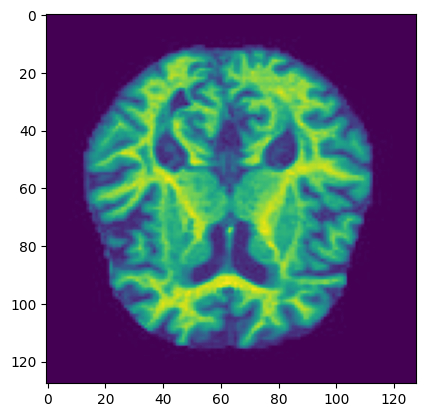

In [ ]:
# display mild_demented image
image=mpimg.imread('/content/Dataset/Mild_Demented/mild_411.jpg')
plot=plt.imshow(image)
plt.show()

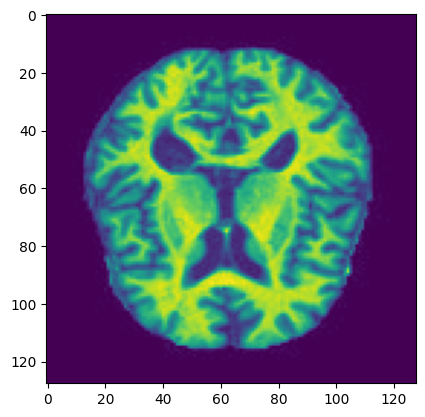

In [ ]:
# displaying Moderate_demented image
image=mpimg.imread('/content/Dataset/Moderate_Demented/moderate_36.jpg')
plot=plt.imshow(image)
plt.show()

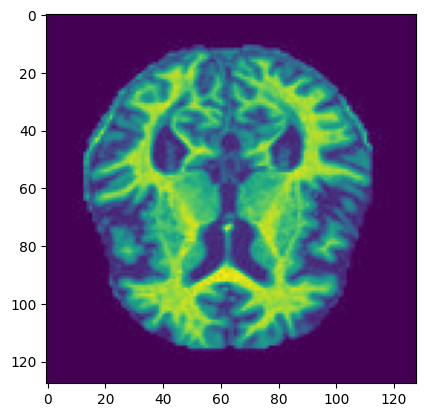

In [ ]:
# displaying Non_demented image
image=mpimg.imread('/content/Dataset/Non_Demented/non_1457.jpg')
plot=plt.imshow(image)
plt.show()

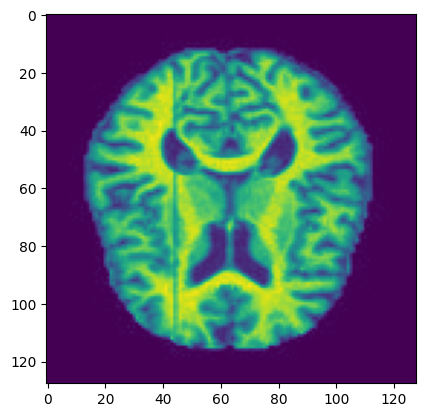

In [ ]:
image=mpimg.imread('/content/Dataset/Very_Mild_Demented/verymild_1337.jpg')
plot=plt.imshow(image)
plt.show()

In [ ]:
# No Resizing of the images is required as all the images are already resized.
# converting images into numpy array
Mild_demented_path='/content/Dataset/Mild_Demented/'
data=[]
for img_file in Mild_demented_files:
  image=Image.open(Mild_demented_path+img_file)
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

Moderate_demented_path='/content/Dataset/Moderate_Demented/'
for img_file in Moderate_demented_files:
  image=Image.open(Moderate_demented_path+img_file)
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

Non_demented_path='/content/Dataset/Non_Demented/'
for img_file in Non_demented_files:
  image=Image.open(Non_demented_path+img_file)
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

very_mild_demented_path='/content/Dataset/Very_Mild_Demented/'
for img_file in very_mild_demented_files:
  image=Image.open(very_mild_demented_path+img_file)
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

In [ ]:
len(data)

6400

In [ ]:
type(data)

list

In [ ]:
data[0]

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [ ]:
data[1]

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [ ]:
type(data[0])

numpy.ndarray

In [ ]:
data[0].shape

(128, 128, 3)

Creating labels

mild_demented -> Label 0

moderate_demented -> Label 1

very_mild_demented -> Label 2

non_demented -> Label 3

In [ ]:
# creating labels
Mild_demented_labels=[0]*896
Moderate_demented_labels=[1]*64
Non_demented_labels=[2]*3200
very_mild_demented_labels=[3]*2240

In [ ]:
print(Mild_demented_labels[0:5])

[0, 0, 0, 0, 0]


In [ ]:
print(very_mild_demented_labels[0:5])

[3, 3, 3, 3, 3]


In [ ]:
labels=Mild_demented_labels+Moderate_demented_labels+Non_demented_labels+very_mild_demented_labels
print(len(labels))

6400


In [ ]:
print(labels[0:5])
print(labels[2000:3000])

[0, 0, 0, 0, 0]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [ ]:
x=np.array(data)
y=np.array(labels)

Train test split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
print(x.shape,x_train.shape,x_test.shape)

(6400, 128, 128, 3) (5120, 128, 128, 3) (1280, 128, 128, 3)


In [ ]:
# scaling the data
x_train_scaled=x_train/255
x_test_scaled=x_test/255

In [ ]:
print(x_train_scaled[0])

[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


Building convolutional neural network

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential

In [ ]:
num_of_classes=4

model=Sequential()
model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes,activation='softmax'))

Compile

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['acc'])

training the neuaral network

In [ ]:
trained=model.fit(x_train_scaled,y_train,validation_split=0.1,epochs=50)

Epoch 1/50
144/144 [==============================] - 120s 825ms/step - loss: 1.1984 - acc: 0.4386 - val_loss: 1.0462 - val_acc: 0.5117
Epoch 2/50
144/144 [==============================] - 119s 828ms/step - loss: 1.0520 - acc: 0.4818 - val_loss: 0.9968 - val_acc: 0.5117
Epoch 3/50
144/144 [==============================] - 119s 826ms/step - loss: 0.9727 - acc: 0.5191 - val_loss: 0.8916 - val_acc: 0.5508
Epoch 4/50
144/144 [==============================] - 116s 806ms/step - loss: 0.8976 - acc: 0.5640 - val_loss: 0.8145 - val_acc: 0.6172
Epoch 5/50
144/144 [==============================] - 116s 804ms/step - loss: 0.8232 - acc: 0.6013 - val_loss: 0.7330 - val_acc: 0.6562
Epoch 6/50
144/144 [==============================] - 116s 805ms/step - loss: 0.7601 - acc: 0.6330 - val_loss: 0.6878 - val_acc: 0.6719
Epoch 7/50
144/144 [==============================] - 120s 833ms/step - loss: 0.6563 - acc: 0.6903 - val_loss: 0.5959 - val_acc: 0.7148
Epoch 8/50
144/144 [============================

Model evaluation

In [ ]:
loss,accuracy=model.evaluate(x_test_scaled,y_test)
print('Test_accuracy',accuracy)

40/40 [==============================] - 18s 436ms/step - loss: 0.1806 - acc: 0.9547
Test_accuracy 0.9546874761581421
